### Configure Jupyter to run plot widgets and import necesssary packages

In [2]:
%matplotlib widget
import numpy as np
import lightkurve as lk
import astropy
from Pyriod import Pyriod

### Import your light curve from Lab 4 and initialize Pyriod

lc_data:
[[0.000000e+00 1.011909e+00]
 [1.000000e+01 1.009146e+00]
 [2.000000e+01 9.953860e-01]
 ...
 [2.157000e+04 1.004844e+00]
 [2.158000e+04 9.730510e-01]
 [2.160000e+04 9.800310e-01]]
lc:
         time                 flux        flux_err
                                                  
---------------------- ------------------ --------
                   0.0 1.0119090024254769      nan
0.00011574074074074075 1.0091460024188543      nan
 0.0002314814814814815 0.9953860023858724      nan
0.00034722222222222224 1.0009980023993241      nan
  0.000462962962962963 0.9975060023909539      nan
 0.0005787037037037037 1.0093630024193743      nan
 0.0006944444444444445 1.0150980024331209      nan
 0.0008101851851851852 1.0184640024411888      nan
  0.000925925925925926 1.0182180024405993      nan
                   ...                ...      ...
    0.2488425925925926 0.9842610023592067      nan
   0.24895833333333334 0.9707760023268839      nan
    0.2490740740740741 0.9573310022946573 

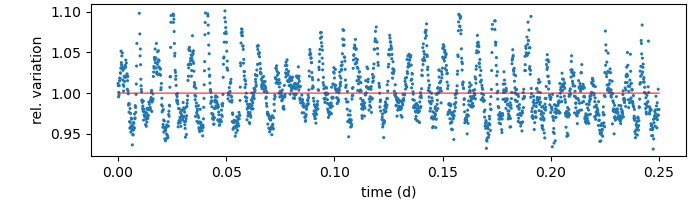

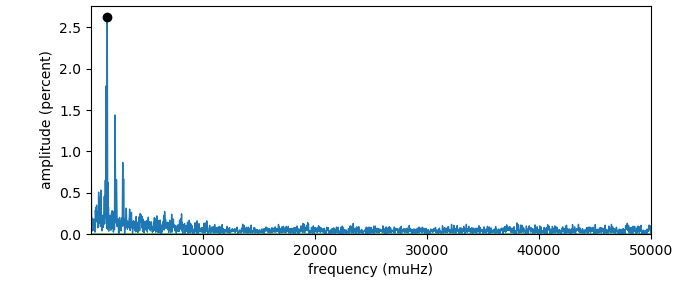

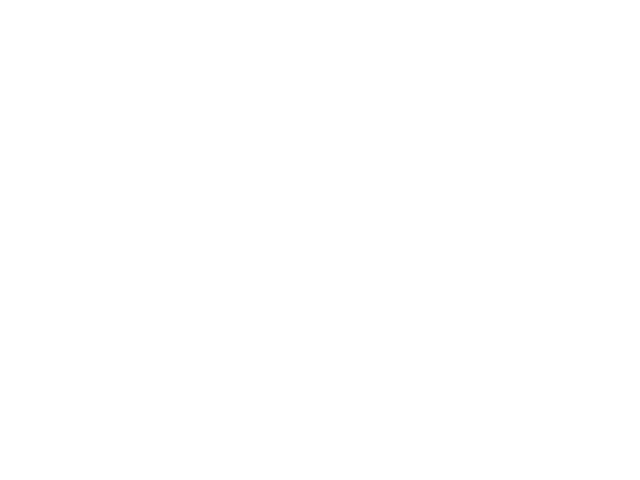

In [14]:
# Import your light curve from last week. You will need to change the name 
# and/or add a path depending on how you organize your directories
lc_data = np.loadtxt('ktwo220274129_lc.txt')
print('lc_data:')
print(lc_data)

# Create a LightCurve object. This code assumes your light curve timestamps are in units
# seconds and converts them to days. If your timestamps are not in seconds, modify the 
# conversion factor as needed to ensure your time variable is in units of days.
# I also have written it to normalize your flux such that its mean = 1, which you should 
# have done in Lab 4, but it won't change anything if you already did so.
time = (lc_data[:,0]-min(lc_data[:,0]))/86400
flux = lc_data[:,1]/np.nanmean(lc_data[:,1])
lc = lk.LightCurve(time=time, flux=flux)
print('lc:')
print(lc)

# Calculate a frequency tolerance in units of uHZ.
# We'll use this to help us chose peaks. Do not select a peak if its distance
# to an already selected peak is smaller than the frequency tolerance.
ftol = 0.5/(max(lc_data[:,0])-min(lc_data[:,0]))*1e6
print(ftol)

# Intilialize Pyriod. If this cell produces any plots, ignore them.
pyriod = Pyriod(lc,amp_unit='percent');
# pyriod = Pyriod(lc,amp_unit='relative');

### Start up the master Pyriod suite. This is what you'll use for the lab.

In [15]:
pyriod.Pyriod()